In [13]:
import argparse
import json
from pathlib import Path
import os
import time
from datetime import timedelta
import sys
sys.path.append("../..")

import numpy as np
import csv
import torch
from torch.utils.tensorboard import SummaryWriter
import torch.nn.functional as F
from monai import transforms
from monai.data import CacheDataset, DataLoader, ThreadDataLoader
from monai.data.utils import pad_list_data_collate
from torch.amp import GradScaler, autocast
from tqdm import tqdm
import random
from monai.utils import first, set_determinism

from monai.inferers import LatentDiffusionInferer
from monai.networks.nets import DiffusionModelUNet, AutoencoderKL
from monai.networks.schedulers import DDPMScheduler

from torch.nn.parallel import DistributedDataParallel as DDP
import torch.distributed as dist

import utils.custom_transforms as custom_transforms
from utils.utils import *
import AnoDDPM.simplex as simplex
import utils.simplex_ddpm as simplex_ddpm

import matplotlib.pyplot as plt

from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    RandAffined,
    RandScaleCropd,
    ResizeWithPadOrCropd,
    ScaleIntensityRangeD,
    RandFlipd,
    Lambdad,
)

In [2]:
def setup_ddp(rank, world_size):
    print(f"Running DDP LDM training on rank {rank}/world_size {world_size}.")
    print(f"Initing to IP {os.environ['MASTER_ADDR']}")
    dist.init_process_group(
        backend="nccl", init_method="env://", timeout=timedelta(seconds=36000), rank=rank, world_size=world_size
    )  # gloo, nccl
    dist.barrier()
    device = torch.device(f"cuda:{rank}")
    return dist, device


In [3]:

# ----------------- SETUP ----------------- #
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"
EXPERIMENT_NAME = "experiment_2"
SUB_EXPERIMENT_NAME = "exp_2_5"
MODELS_DIR = ROOT_DIR+f"AnoDiffExperiments/{EXPERIMENT_NAME}/{SUB_EXPERIMENT_NAME}/models/"
os.makedirs(MODELS_DIR, exist_ok=True)

ddp_bool = False  # whether to use distributed data parallel

if ddp_bool:
    rank = int(os.environ["LOCAL_RANK"])
    world_size = int(os.environ["WORLD_SIZE"])
    dist, device = setup_ddp(rank, world_size)
else:
    rank = 0
    world_size = 1
    device = 0

torch.cuda.set_device(device)
print(f"Using {device}")

torch.backends.cudnn.benchmark = True
torch.set_num_threads(torch.get_num_threads()) 
torch.autograd.set_detect_anomaly(False)


Using 0


In [4]:

# ----------------- DATASET AND DATALOADER ----------------- #
test_csv = os.path.join(ROOT_DIR, f"AnoDiffExperiments/data_splits_lists/final_flair_dataset_small_added_oasis/test.csv")
test_images_path = []

with open(test_csv, mode='r') as file:
    reader = csv.reader(file)
    for line in tqdm(reader):
        #print(line)
        test_images_path.append(ROOT_DIR+line[0])


test_datalist = test_images_path

batch_size = 4
num_workers = 8


169it [00:00, 99179.71it/s]


In [5]:

# Validation transforms
test_transforms = Compose([
    transforms.LoadImage(image_only=True),
    transforms.EnsureChannelFirst(),
    transforms.ResizeWithPadOrCrop(spatial_size=[128, 128, 128]),  # replace with actual image_size
    custom_transforms.ScaleIntensityFromHistogramPeak(target_value=200.0),
    transforms.ScaleIntensityRange(a_min=0.0, a_max=700.0, b_min=0.0, b_max=1.0, clip=True),
    custom_transforms.SetBackgroundToZero()
])

# Update datalists to use image paths directly (not dictionaries)
test_datalist = test_images_path

# Create datasets
test_ds = CacheDataset(data=test_datalist[:batch_size], transform=test_transforms) #TODO

# Create samplers and dataloaders (as in your original code)
if ddp_bool:
    test_sampler = torch.utils.data.distributed.DistributedSampler(test_ds, num_replicas=world_size, rank=rank)
else:
    test_sampler = None
    
test_loader = DataLoader(
    test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True, sampler=test_sampler
)


Loading dataset: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:05<00:00,  1.39s/it]


In [6]:

# ----------------- MODEL, OPTIMIZER, LOSS, LR SCHEDULER ----------------- #
# Define Autoencoder KL network and diffusion model
# Load Autoencoder KL network

LATENT_CHANNELS=8

autoencoder = AutoencoderKL(
        spatial_dims=3,
        in_channels=1,
        out_channels=1,
        latent_channels=LATENT_CHANNELS,
        channels=[
            64,
            128,
            256
        ],
        num_res_blocks=2,
        norm_num_groups=32,
        norm_eps=1e-06,
        attention_levels=[
            False,
            False,
            False
        ],
        with_encoder_nonlocal_attn=False,
        with_decoder_nonlocal_attn=False
    ).to(device)

trained_g_path = os.path.join(MODELS_DIR, f"{SUB_EXPERIMENT_NAME}_autoencoder.pt")

map_location = {"cuda:%d" % 0: "cuda:%d" % rank}
autoencoder.load_state_dict(torch.load(trained_g_path, map_location=map_location, weights_only=True))
print(f"Rank {rank}: Load trained autoencoder from {trained_g_path}")

Rank 0: Load trained autoencoder from /bettik/PROJECTS/pr-gin5_aini/fehrdelt/AnoDiffExperiments/experiment_2/exp_2_5/models/exp_2_5_autoencoder.pt


In [7]:
if rank==0:
        os.makedirs(ROOT_DIR+f"AnoDiffExperiments/tensorboard/{SUB_EXPERIMENT_NAME}", exist_ok=True)
        writer = SummaryWriter(ROOT_DIR+f"AnoDiffExperiments/tensorboard/{SUB_EXPERIMENT_NAME}")


# Compute Scaling factor
# As mentioned in Rombach et al. [1] Section 4.3.2 and D.1, the signal-to-noise ratio (induced by the scale of the latent space) can affect the results obtained with the LDM,
# if the standard deviation of the latent space distribution drifts too much from that of a Gaussian.
# For this reason, it is best practice to use a scaling factor to adapt this standard deviation.
# _Note: In case where the latent space is close to a Gaussian distribution, the scaling factor will be close to one,
# and the results will not differ from those obtained when it is not used._

with torch.no_grad():
    with autocast("cuda", enabled=True):
        check_data = first(test_loader)
        z = autoencoder.encode_stage_2_inputs(check_data.to(device))
        if rank == 0:
            print(f"Latent feature shape {z.shape}")
            for axis in range(3):
                writer.add_image(
                    "train_img_" + str(axis),
                    visualize_one_slice_in_3d_image(check_data[0, 0, ...], axis).transpose([2, 1, 0]),
                    1,
                )
            print(f"Scaling factor set to {1/torch.std(z)}")

scale_factor = 1 / torch.std(z)
print(f"Rank {rank}: local scale_factor: {scale_factor}")
if ddp_bool:
    dist.barrier()
    dist.all_reduce(scale_factor, op=torch.distributed.ReduceOp.AVG)
print(f"Rank {rank}: final scale_factor -> {scale_factor}")

Latent feature shape torch.Size([4, 8, 32, 32, 32])
Scaling factor set to 0.9982261061668396
Rank 0: local scale_factor: 0.9982261061668396
Rank 0: final scale_factor -> 0.9982261061668396


In [ ]:
# Define Diffusion Model
unet = DiffusionModelUNet(
        spatial_dims=3,
        in_channels=LATENT_CHANNELS,
        out_channels=LATENT_CHANNELS,
        channels=[32, 64, 64, 64],
        attention_levels=[False, True, True, True],
        num_head_channels=8,
        use_flash_attention=True).to(device)

trained_diffusion_path = os.path.join(MODELS_DIR, f"{SUB_EXPERIMENT_NAME}_diffusion_unet.pt")
trained_diffusion_path_last = os.path.join(MODELS_DIR, f"{SUB_EXPERIMENT_NAME}_diffusion_unet_last.pt")

unet.load_state_dict(torch.load(trained_diffusion_path, map_location="cuda:0"))
unet.eval()

scheduler = DDPMScheduler(
    num_train_timesteps=1000,
    schedule="scaled_linear_beta",
    beta_start=0.0015,
    beta_end=0.0195,
)

if ddp_bool:
    autoencoder = DDP(autoencoder, device_ids=[device], output_device=rank, find_unused_parameters=True)
    unet = DDP(unet, device_ids=[device], output_device=rank, find_unused_parameters=True)

# We define the inferer using the scale factor:
inferer = LatentDiffusionInferer(scheduler, scale_factor=scale_factor)


In [16]:
optimizer_diff = torch.optim.Adam(params=unet.parameters(), lr=1e-5 * world_size)
lr_scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer_diff, milestones=[100, 1000], gamma=0.1)


### inference on test dataset

In [22]:
infer_timesteps = 200

for step, batch in enumerate(test_loader):

    if step>0:break  # only one batch for checking

    images = batch.to(device)
    optimizer_diff.zero_grad(set_to_none=True)

    with torch.no_grad():
        with autocast("cuda", enabled=True):

            latents = autoencoder.encode_stage_2_inputs(images)    

            # Add noise to latents
            noise = torch.randn_like(latents).to(device)
            timesteps = torch.randint(0, scheduler.num_train_timesteps, (latents.shape[0],), device=device).long()
            noisy_latents = scheduler.add_noise(latents, noise, timesteps)
            
            # Denoise completely using the UNet
            scheduler.set_timesteps(scheduler.num_train_timesteps)
            current_latents = noisy_latents * scale_factor
            
            for t in tqdm(range(infer_timesteps-1, -1, -1)):
                noise_pred = unet(current_latents, timesteps=torch.tensor([t], device=device).expand(latents.shape[0]))
                current_latents, _ = scheduler.step(noise_pred, t, current_latents)
            
            # Decode the denoised latents
            current_latents = current_latents / scale_factor
            reconstructed_images = autoencoder.decode(current_latents)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:13<00:00, 14.84it/s]


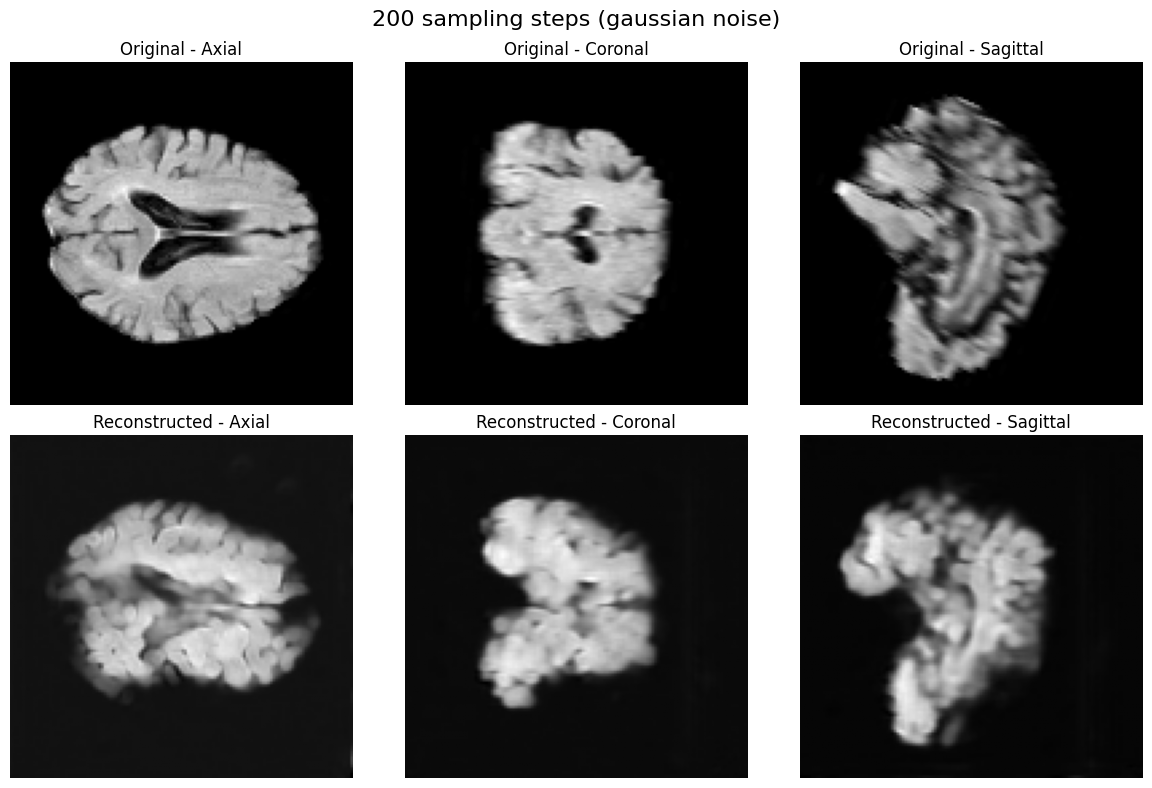

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Get middle slices indices
mid_axial = images.shape[4] // 2
mid_coronal = images.shape[3] // 2
mid_sagittal = images.shape[2] // 2

# Original images (first sample in batch)
axes[0, 0].imshow(images[0, 0, :, :, mid_axial].cpu().numpy(), cmap='gray')
axes[0, 0].set_title('Original - Axial')
axes[0, 1].imshow(images[0, 0, :, mid_coronal, :].cpu().numpy(), cmap='gray')
axes[0, 1].set_title('Original - Coronal')
axes[0, 2].imshow(images[0, 0, mid_sagittal, :, :].cpu().numpy(), cmap='gray')
axes[0, 2].set_title('Original - Sagittal')

# Reconstructed images
axes[1, 0].imshow(reconstructed_images[0, 0, :, :, mid_axial].cpu().numpy(), cmap='gray')
axes[1, 0].set_title('Reconstructed - Axial')
axes[1, 1].imshow(reconstructed_images[0, 0, :, mid_coronal, :].cpu().numpy(), cmap='gray')
axes[1, 1].set_title('Reconstructed - Coronal')
axes[1, 2].imshow(reconstructed_images[0, 0, mid_sagittal, :, :].cpu().numpy(), cmap='gray')
axes[1, 2].set_title('Reconstructed - Sagittal')

for ax in axes.flat:
    ax.axis('off')

plt.suptitle(f"{infer_timesteps} sampling steps (gaussian noise)", fontsize=16)

plt.tight_layout()
plt.show()